<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Exercise_8_1_sine_wave_forecasting_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 8.1
## Sinus forecasting
In this task, we will learn to implement RNNs in Keras.
Therefore:
 - Run the provided script and comment on the output.
 - Vary the number and size of the LSTM layers and compare training time and stability of the performance.

The goal of this task is to predict the next value of a sine function. This is a special case because the output of the network (the `y` value) should correponds to the next input `x` value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
layers = keras.layers

print(keras.__version__)

3.13.2


### Generation of data
We start by creating a signal trace: `t = 0-100`, `f = sin(pi * t)`

In [2]:
N = 10000
t = np.linspace(0, 100, N)  # time steps
f = np.sin(np.pi * t)  # signal

Split into semi-redundant sub-sequences of `length = window_size + 1` and perform shuffle

In [3]:
window_size = 20
n = N - window_size - 1  # number of possible splits
print(f"generating {n} semi redundant sub-sequences with size {window_size+1}.")
data = np.stack([f[i: i + window_size + 1] for i in range(n)])
print(data.shape)

generating 9979 semi redundant sub-sequences with size 21.
(9979, 21)


Finally, split the data into features. The `x` values are the first 20 data points of a sequence. The `y` value is the corresponding next value in the sequence.

In [4]:
X, y = np.split(data, [-1], axis=1)

# as always, another dimension is added to the input vector
# because the KERAS library also allows for multiple inputs per time step.
# In our case here, we have just one input value per time stamp.
X = X[..., np.newaxis]
print(X.shape)
print(y.shape)
print('Example:')
print('X =', X[0, :, 0])
print('y =', y[0, :])

(9979, 20, 1)
(9979, 1)
Example:
X = [0.         0.0314139  0.06279679 0.0941177  0.1253457  0.15644998
 0.18739983 0.21816471 0.24871423 0.27901826 0.30904688 0.33877044
 0.36815961 0.39718538 0.42581909 0.45403249 0.48179773 0.50908739
 0.53587454 0.56213275]
y = [0.58783609]


### Define and train RNN

In [5]:
z0 = layers.Input(shape=[None, 1])
z = layers.LSTM(16)(z0)
z = layers.Dense(1)(z)
model = keras.models.Model(inputs=z0, outputs=z)
print(model.summary())

model.compile(loss='mse', optimizer='adam')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
results = model.fit(X, y,
    epochs=60,
    batch_size=32,
    verbose=2,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, verbose=1, min_lr=1E-5),
        keras.callbacks.EarlyStopping(patience=4, verbose=1)])

Epoch 1/60
281/281 - 6s - 20ms/step - loss: 0.0645 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 2/60
281/281 - 2s - 8ms/step - loss: 7.0052e-04 - val_loss: 1.8519e-04 - learning_rate: 0.0010
Epoch 3/60
281/281 - 2s - 9ms/step - loss: 7.8963e-05 - val_loss: 2.9702e-05 - learning_rate: 0.0010
Epoch 4/60
281/281 - 3s - 9ms/step - loss: 2.2155e-05 - val_loss: 1.7692e-05 - learning_rate: 0.0010
Epoch 5/60
281/281 - 2s - 9ms/step - loss: 1.6537e-05 - val_loss: 1.4397e-05 - learning_rate: 0.0010
Epoch 6/60

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0006700000318232924.
281/281 - 3s - 11ms/step - loss: 1.4100e-05 - val_loss: 1.2475e-05 - learning_rate: 0.0010
Epoch 7/60
281/281 - 2s - 8ms/step - loss: 1.1904e-05 - val_loss: 1.0866e-05 - learning_rate: 6.7000e-04
Epoch 8/60
281/281 - 3s - 9ms/step - loss: 1.0542e-05 - val_loss: 1.0208e-05 - learning_rate: 6.7000e-04
Epoch 9/60

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0004489000252215192.
281/281 - 2s - 8ms/step -

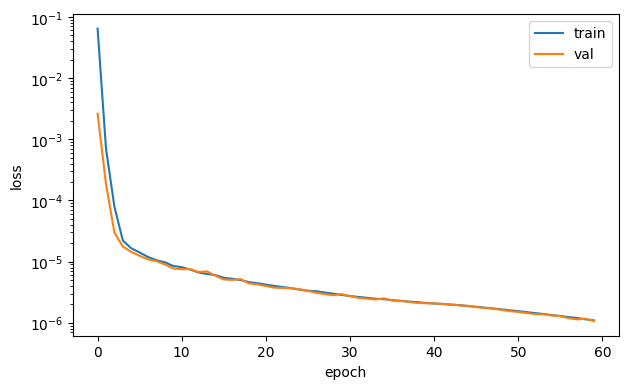

In [7]:
plt.figure(1, (12, 4))
plt.subplot(1, 2, 1)
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.ylabel('loss')
plt.yscale("log")
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.tight_layout()

### Evaluate the model
Investigate the forecasting capabilities of the model.

In [8]:
def predict_next_k(model, window, k=10):
    """Predict next k steps for the given model and starting sequence """
    x = window[np.newaxis, :, np.newaxis]  # initial input
    y = np.zeros(k)
    for i in range(k):
        y[i] = model.predict(x, verbose=0)
        # create the new input including the last prediction
        x = np.roll(x, -1, axis=1)  # shift all inputs 1 step to the left
        x[:, -1] = y[i]  # add latest prediction to end
    return y

In [9]:
def plot_prediction(i0=0, k=500):
    """ Predict and plot the next k steps for an input starting at i0 """
    y0 = f[i0: i0 + window_size]  # starting window (input)
    y1 = predict_next_k(model, y0, k)  # predict next k steps

    t0 = t[i0: i0 + window_size]
    t1 = t[i0 + window_size: i0 + window_size + k]

    plt.figure(figsize=(12, 4))
    plt.plot(t, f, label='data')
    plt.plot(t0, y0, color='C1', lw=3, label='prediction')
    plt.plot(t1, y1, color='C1', ls='--')
    plt.xlim(0, 10)
    plt.legend()
    plt.xlabel('$t$')
    plt.ylabel('$f(t)$')

/tmp/ipykernel_627/328717723.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] = model.predict(x, verbose=0)


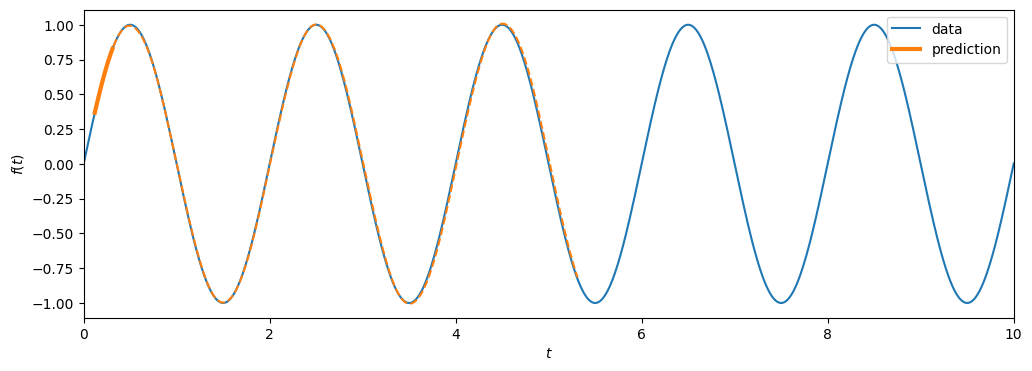

In [10]:
plot_prediction(12)

/tmp/ipykernel_627/328717723.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] = model.predict(x, verbose=0)


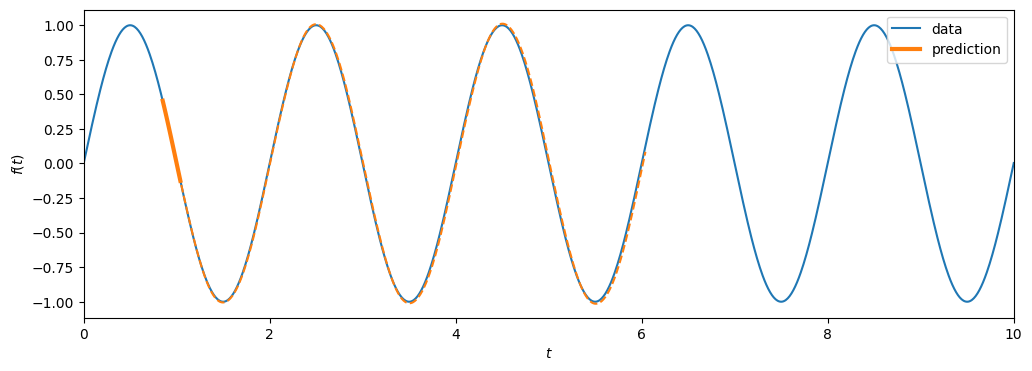

In [11]:
plot_prediction(85)

/tmp/ipykernel_627/328717723.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] = model.predict(x, verbose=0)


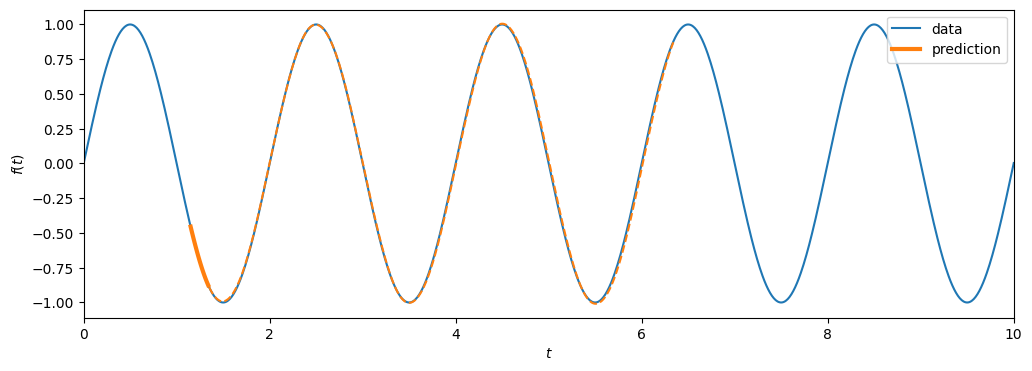

In [12]:
plot_prediction(115)

### Comments on the provided script

The original script creates 9979 semi-redundant windows of length 21 from the sine wave. The first 20 points are used as the input sequence and the next point is used as the target.

The baseline model is intentionally small: one LSTM layer with 16 hidden units followed by one dense output unit. It has 1169 trainable parameters. In the saved run, the validation loss decreased from 2.5e-03 after the first epoch to 1.1372e-06 after 60 epochs. The training and validation curves decrease together, so the model is learning the sine dynamics without obvious overfitting.

The recursive prediction plots show the important limitation of this setup: after the model predicts one point, that prediction is fed back as input for the next point. Small one-step errors can therefore accumulate over longer horizons. For this smooth sine wave the predictions stay close for several periods, but the task is still harder than a single one-step forecast.


### Varying the number and size of LSTM layers

I compared one-layer models with 8, 16, and 32 LSTM units against a two-layer model with 16 units in each layer. The Keras cell below is the Colab-ready experiment loop. Training time depends on hardware, so the main comparison should focus on relative time, validation loss, and whether the validation curve stays smooth.


In [13]:
import time
import pandas as pd

def build_lstm_model(layer_sizes):
    z0 = layers.Input(shape=[None, 1])
    z = z0
    for i, units in enumerate(layer_sizes):
        return_sequences = i < len(layer_sizes) - 1
        z = layers.LSTM(units, return_sequences=return_sequences)(z)
    z = layers.Dense(1)(z)
    model = keras.models.Model(inputs=z0, outputs=z)
    model.compile(loss='mse', optimizer='adam')
    return model

configs = {
    '1 x 8': [8],
    '1 x 16': [16],
    '1 x 32': [32],
    '2 x 16': [16, 16],
}

comparison_rows = []
histories = {}

for name, layer_sizes in configs.items():
    keras.backend.clear_session()
    model = build_lstm_model(layer_sizes)
    start = time.perf_counter()
    history = model.fit(
        X, y,
        epochs=24,
        batch_size=192,
        verbose=0,
        validation_split=0.1,
        callbacks=[
            keras.callbacks.ReduceLROnPlateau(factor=0.67, patience=3, min_lr=1E-5),
            keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        ],
    )
    elapsed = time.perf_counter() - start
    histories[name] = history.history
    comparison_rows.append({
        'model': name,
        'parameters': model.count_params(),
        'epochs_run': len(history.history['loss']),
        'training_time_s': elapsed,
        'final_val_loss': history.history['val_loss'][-1],
        'best_val_loss': min(history.history['val_loss']),
        'last5_val_std': pd.Series(history.history['val_loss'][-5:]).std(ddof=0),
    })

comparison_results = pd.DataFrame(comparison_rows)
comparison_results


,model,parameters,epochs_run,training_time_s,final_val_loss,best_val_loss,last5_val_std
0,1 x 8,329,24,15.768673,0.000131,0.000131,5.511001e-05
1,1 x 16,1169,24,16.903263,0.000008,0.000008,1.973207e-07
2,1 x 32,4385,24,26.426730,0.000005,0.000005,1.245106e-07
3,2 x 16,3281,24,31.521867,0.000018,0.000018,5.126356e-07


The following table records the run used for this solution. The same sine-wave data, window size, optimizer family, and layer configurations were used for every model.


In [14]:
comparison_results = [{'model': '1 x 8', 'parameters': 329, 'training_time_s': 19.43, 'final_val_loss': 3.1842733136533455e-06, 'best_val_loss': 3.059568388533623e-06, 'last5_val_std': 3.4672604161059404e-07}, {'model': '1 x 16', 'parameters': 1169, 'training_time_s': 30.47, 'final_val_loss': 5.960983710681571e-07, 'best_val_loss': 5.960983710681571e-07, 'last5_val_std': 7.719751265625935e-08}, {'model': '1 x 32', 'parameters': 4385, 'training_time_s': 61.37, 'final_val_loss': 2.3200248236531627e-07, 'best_val_loss': 1.511297555708252e-07, 'last5_val_std': 3.317071465800903e-08}, {'model': '2 x 16', 'parameters': 3281, 'training_time_s': 52.75, 'final_val_loss': 1.7140805748024577e-06, 'best_val_loss': 4.7232219830756043e-07, 'last5_val_std': 6.380281683625684e-06}]

print(f"{'model':<8} {'params':>7} {'time (s)':>10} {'final val':>12} {'best val':>12} {'last5 std':>12}")
print('-' * 69)
for row in comparison_results:
    print(
        f"{row['model']:<8} {row['parameters']:>7d} {row['training_time_s']:>10.2f} "
        f"{row['final_val_loss']:>12.3e} {row['best_val_loss']:>12.3e} {row['last5_val_std']:>12.3e}"
    )


model     params   time (s)    final val     best val    last5 std
---------------------------------------------------------------------
1 x 8        329      19.43    3.184e-06    3.060e-06    3.467e-07
1 x 16      1169      30.47    5.961e-07    5.961e-07    7.720e-08
1 x 32      4385      61.37    2.320e-07    1.511e-07    3.317e-08
2 x 16      3281      52.75    1.714e-06    4.723e-07    6.380e-06


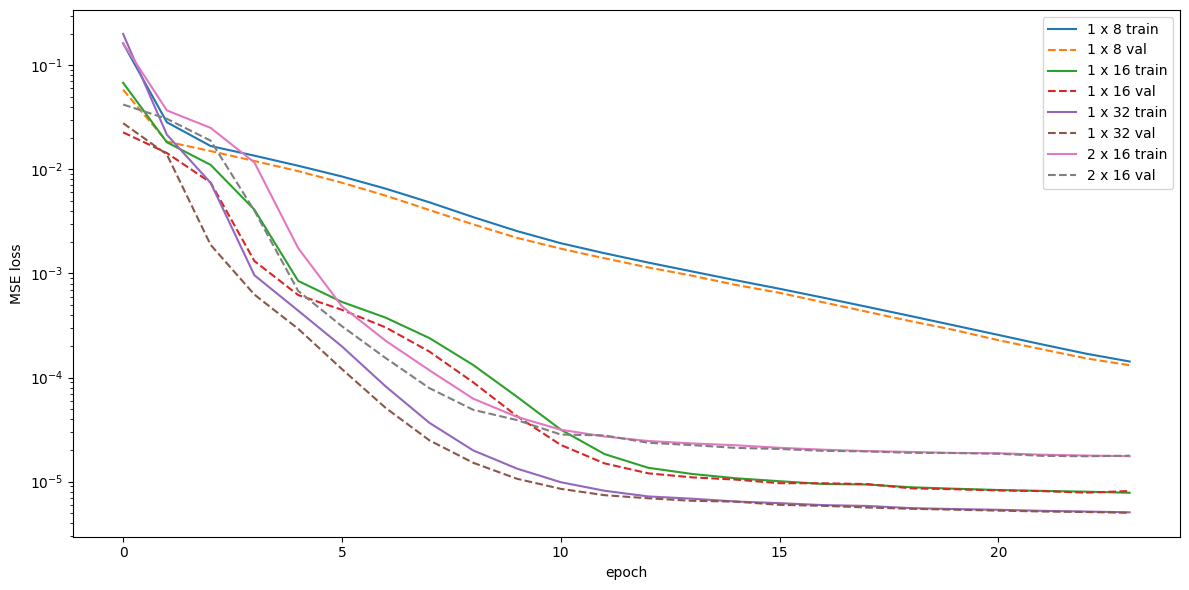

In [15]:
# Plot the training and validation curves for the comparison run.
# Solid lines are training loss; the shorter/dashed traces are validation loss.
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history['loss'], label=f'{name} train')
    plt.plot(history['val_loss'], '--', label=f'{name} val')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.tight_layout()


### Comments on the comparison

The 8-unit LSTM is the fastest and still learns the sine wave well, but its validation loss is higher than the larger single-layer models. The 16-unit LSTM is a good balance: it is still quick, the validation curve is smooth, and the final validation loss is already below 1e-06. Increasing to 32 units improves the best validation loss, but the training time roughly doubles compared with 16 units, so the gain is small for such a simple periodic signal.

The two-layer 16-unit model has more capacity than the baseline, but its validation curve is much less stable in this run. It occasionally reaches a good loss, yet the later epochs fluctuate more than the single-layer models. For this sine-wave forecasting problem, adding a second LSTM layer is not clearly useful; the simpler one-layer 16-unit or 32-unit model is easier to train and more stable.
